# HDB Resale Price — Exploratory Data Analysis

**Business problem.** Cataria Property Solutions wants consistent, data-driven HDB resale
valuations. We predict `resale_price` (a continuous dollar value) from transaction
attributes, so this is a **regression** problem.

**Goal of this notebook.** Understand the raw data, surface and document every data-quality
issue, engineer the features the model will use, study how each feature relates to the
target, and end with an explicit list of preprocessing decisions that the pipeline
(`src/data_preparation.py`, `src/model_training.py`) then implements. Every cleaning rule
below is mirrored in the pipeline so the analysis and the model stay in sync.

## 1. Setup and data loading

In [1]:
import sys, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sys.path.append(".")            # so we can import the project's own pipeline code
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

with open("src/config.yaml") as f:
    config = yaml.safe_load(f)

TARGET = config["target_column"]
df = pd.read_csv(config["file_path"])
print("Shape:", df.shape, "| target:", TARGET)
df.head()

Shape: (88688, 14) | target: resale_price


,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  str    
 2   flat_type            88688 non-null  str    
 3   block                88688 non-null  str    
 4   street_name          88688 non-null  str    
 5   storey_range         88688 non-null  str    
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  str    
 9   resale_price         88688 non-null  float64
 10  town_id              88688 non-null  int64  
 11  flatm_id             88688 non-null  int64  
 12  town_name            87905 non-null  str    
 13  flatm_name           88174 non-null  str    
dtypes: float64(2), int64(4), str(8)
memory usage: 9.5 MB


**First observations.**

- ~88.7k transactions, 14 columns. The target is `resale_price`.
- Numeric-looking: `floor_area_sqm`, `lease_commence_date`, `resale_price`, plus id-like
  `id`, `town_id`, `flatm_id`.
- Text/categorical: `month` (a `YYYY-MM` string), `flat_type`, `block`, `street_name`,
  `storey_range`, `remaining_lease`, `town_name`, `flatm_name`.
- `month`, `storey_range` and `remaining_lease` are stored as text but clearly encode
  numeric/temporal information — they will need engineering before modelling.

## 2. Data quality checks

In [3]:
# Missing values
missing = df.isna().sum()
missing[missing > 0].to_frame("missing_count").assign(
    pct=lambda d: (d["missing_count"] / len(df) * 100).round(2))

,missing_count,pct
town_name,783,0.88
flatm_name,514,0.58


In [4]:
# Exact duplicate rows
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated 'id' values :", df["id"].duplicated().sum())

Fully duplicated rows: 4223
Duplicated 'id' values : 4223


In [5]:
# Invalid / inconsistent values
print("Negative lease_commence_date values:", (df["lease_commence_date"] < 0).sum(),
      "| raw range:", df["lease_commence_date"].min(), "to", df["lease_commence_date"].max())
print("\nflat_type value counts (note the 'FOUR ROOM' typo):")
print(df["flat_type"].value_counts())

rl = df["remaining_lease"].astype(str)
print("\nremaining_lease is stored in TWO formats:")
print("  bare number  e.g. '81'                :", rl.str.match(r"^\d+$").sum())
print("  'X years Y months' e.g. '70 years 03 months':", rl.str.contains("year").sum())

Negative lease_commence_date values: 9394 | raw range: -2016 to 2016

flat_type value counts (note the 'FOUR ROOM' typo):
flat_type
4 ROOM              34741
3 ROOM              22557
5 ROOM              21484
EXECUTIVE            7017
FOUR ROOM            1824
2 ROOM                991
1 ROOM                 39
MULTI-GENERATION       35
Name: count, dtype: int64

remaining_lease is stored in TWO formats:
  bare number  e.g. '81'                : 36824
  'X years Y months' e.g. '70 years 03 months': 51864


**Data-quality findings.**

1. **Missing town/flat-model names** — `town_name` (783) and `flatm_name` (514) are missing,
   but each row still carries the numeric `town_id` / `flatm_id`. We can recover the names
   from an id→name mapping learned from the non-missing rows, so no rows need dropping.
2. **Duplicate rows** — 4,223 fully duplicated transactions (same `id`). These are dropped
   so repeated records don't bias the model.
3. **Corrupt `lease_commence_date`** — 9,394 rows have a *negative* year (down to −2016). A
   commencement year can't be negative; the sign is a data-entry corruption, fixed with an
   absolute value.
4. **`flat_type` label inconsistency** — `"FOUR ROOM"` (1,824 rows) is the same as `"4 ROOM"`;
   they must be merged before the ordinal encoder sees them.
5. **Mixed `remaining_lease` format** — half the rows are a bare year count (`"81"`), half are
   verbose (`"70 years 03 months"`). A single parser must handle both and return whole months.

## 3. Target variable analysis

count      88688.0
mean      438679.0
std       146670.0
min       160000.0
25%       335000.0
50%       408000.0
75%       505000.0
max      1200000.0
Name: resale_price, dtype: float64

Skew: 1.214


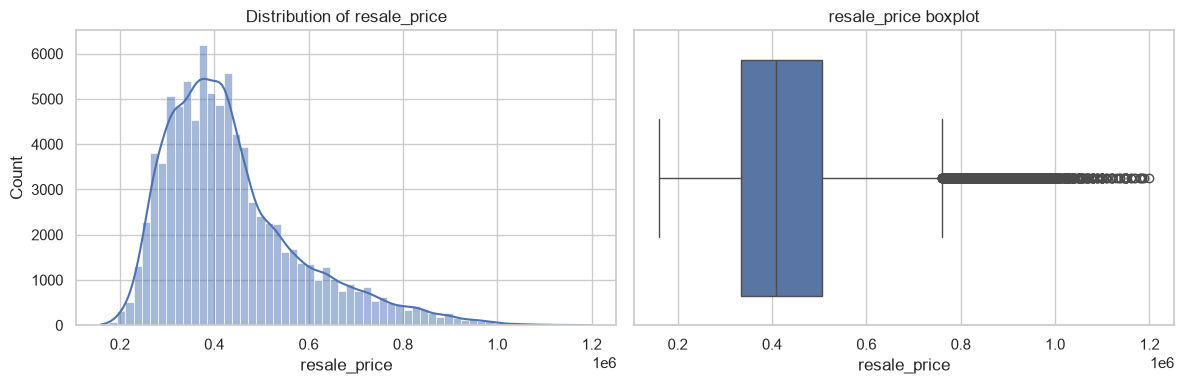

In [6]:
print(df[TARGET].describe().round(0))
print("\nSkew:", round(df[TARGET].skew(), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=ax[0])
ax[0].set_title("Distribution of resale_price")
sns.boxplot(x=df[TARGET], ax=ax[1])
ax[1].set_title("resale_price boxplot")
plt.tight_layout(); plt.show()

**Target observations.** Prices run from ~160k to 1.2M, mean ~439k above median ~408k, so the
distribution is **right-skewed** with a long upper tail (larger/executive flats). There are no
missing or non-positive prices. Because we will lean on tree-based models (robust to skew and
monotonic transforms), we model the raw price rather than a log transform, but the skew is
worth remembering when reading error metrics.

## 4. Feature engineering & validation

Rather than re-implement the transformations here, we import the project's own
`DataPreparation` class and apply it, then verify the engineered columns on sample rows. This
guarantees the EDA is validating the *exact* logic the model will use.

In [7]:
from src.data_preparation import DataPreparation

prep = DataPreparation(config)
clean = prep.clean_data(df.copy())
print("Raw shape:", df.shape, "-> cleaned shape:", clean.shape)
print("Cleaned columns:", list(clean.columns))
clean.head()

C:\Users\tecks\OneDrive\Desktop\AIAP\regression-end-to-end\src\data_preparation.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["flat_type"].replace("FOUR ROOM", "4 ROOM", inplace=True)


Raw shape: (88688, 14) -> cleaned shape: (84465, 10)
Cleaned columns: ['month', 'flat_type', 'storey_range', 'floor_area_sqm', 'lease_commence_date', 'resale_price', 'town_name', 'flatm_name', 'year', 'remaining_lease_months']


,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,resale_price,town_name,flatm_name,year,remaining_lease_months
0,5,5 ROOM,8.0,123.0,1989,488000.0,PASIR RIS,Improved,2018,843
1,10,4 ROOM,2.0,100.0,1999,345000.0,SENGKANG,Model A,2016,972
2,10,5 ROOM,20.0,110.0,2002,370000.0,CHOA CHU KANG,Improved,2018,990
3,12,4 ROOM,14.0,103.0,1984,432000.0,HOUGANG,Model A,2015,804
4,9,5 ROOM,8.0,122.0,1992,500000.0,SERANGOON,Improved,2017,890


In [8]:
# Spot-check the three engineered transforms against the raw values
check = df.copy()
check_clean = prep.clean_data(df.copy())
sample = pd.DataFrame({
    "storey_range_raw": df["storey_range"].head(6).values,
    "storey_mid":       check_clean["storey_range"].head(6).values,
    "month_raw":        df["month"].head(6).values,
    "year":             check_clean["year"].head(6).values,
    "remaining_lease_raw":    df["remaining_lease"].head(6).values,
    "remaining_lease_months": check_clean["remaining_lease_months"].head(6).values,
})
sample

C:\Users\tecks\OneDrive\Desktop\AIAP\regression-end-to-end\src\data_preparation.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["flat_type"].replace("FOUR ROOM", "4 ROOM", inplace=True)


,storey_range_raw,storey_mid,month_raw,year,remaining_lease_raw,remaining_lease_months
0,07 TO 09,8.0,2018-05,2018,70 years 03 months,843
1,01 TO 03,2.0,2016-10,2016,81,972
2,19 TO 21,20.0,2018-10,2018,82 years 06 months,990
3,13 TO 15,14.0,2015-12,2015,67,804
4,07 TO 09,8.0,2017-09,2017,74 years 02 months,890
5,04 TO 06,5.0,2018-09,2018,61 years 04 months,736


**Validation.** `storey_range` becomes its band midpoint (e.g. `07 TO 09` → 8), `month`
becomes a numeric `year` + `month`, and both `remaining_lease` formats resolve to a single
`remaining_lease_months` integer. High-cardinality address fields (`block`, `street_name`) and
the id columns are dropped in the same step.

## 5. Categorical feature profiling


flat_type — 8 categories
flat_type
4 ROOM              34741
3 ROOM              22557
5 ROOM              21484
EXECUTIVE            7017
FOUR ROOM            1824
2 ROOM                991
1 ROOM                 39
MULTI-GENERATION       35

town_name — 26 categories
town_name
JURONG WEST    6865
WOODLANDS      6575
SENGKANG       6481
TAMPINES       5893
YISHUN         5124
BEDOK          4993
PUNGGOL        4682
HOUGANG        4303

flatm_name — 21 categories
flatm_name
Model A              27536
Improved             22363
New Generation       13676
Premium Apartment     9051
Simplified            3888
Apartment             3384
Maisonette            2560
Standard              2492


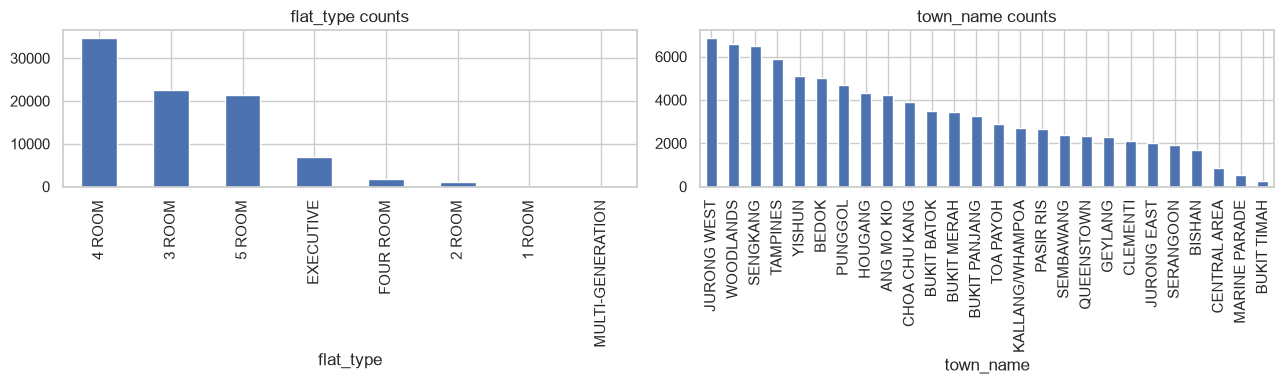

In [9]:
for col in ["flat_type", "town_name", "flatm_name"]:
    vc = df[col].value_counts(dropna=False)
    print(f"\n{col} — {df[col].nunique()} categories")
    print((vc.head(8)).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["flat_type"].value_counts().plot(kind="bar", ax=ax[0], title="flat_type counts")
df["town_name"].value_counts().plot(kind="bar", ax=ax[1], title="town_name counts")
plt.tight_layout(); plt.show()

**Categorical observations.**

- **`flat_type`** is dominated by 3/4/5-ROOM; `1 ROOM` (39) and `MULTI-GENERATION` (35) are very
  rare. It has a natural size ordering, so it is **ordinal-encoded** with an explicit category
  order (and `FOUR ROOM` merged in).
- **`town_name`** (26) and **`flatm_name`** (21) are moderate-cardinality nominal fields with no
  inherent order → **one-hot encoded** (`handle_unknown="ignore"` so unseen towns at inference
  don't break prediction).
- **`storey_range`** has 17 clean, ordered bands → converted to a numeric midpoint rather than
  encoded, preserving the height ordering cheaply.

## 6. High-cardinality & leakage checks

In [10]:
card = df.nunique().sort_values(ascending=False).to_frame("n_unique")
card["pct_of_rows"] = (card["n_unique"] / len(df) * 100).round(2)
card

,n_unique,pct_of_rows
id,84465,95.24
resale_price,2494,2.81
block,2324,2.62
remaining_lease,654,0.74
street_name,535,0.60
floor_area_sqm,165,0.19
lease_commence_date,101,0.11
month,54,0.06
town_id,26,0.03
town_name,26,0.03


**Leakage / cardinality decision.** `id` is a unique row key (pure identifier). `block` (2,324)
and `street_name` (535) are near-address-level labels: encoding them would explode the feature
space and let the model memorise individual addresses (a leakage-like effect that won't
generalise). Location is already captured more robustly by `town_name`. All three are dropped.
`town_id` / `flatm_id` are kept only long enough to back-fill the missing names, then dropped.

## 7. Feature–target relationships

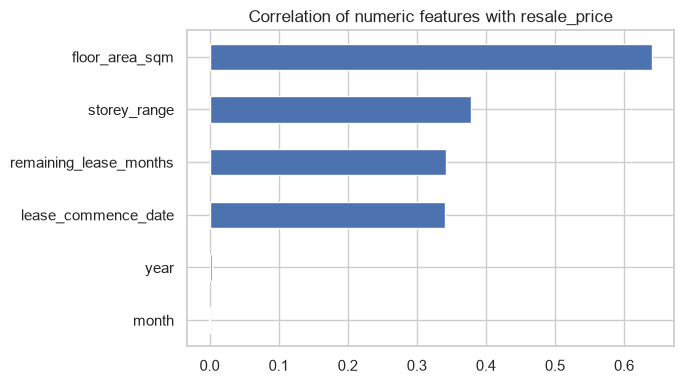

month                    -0.000
year                      0.003
lease_commence_date       0.341
remaining_lease_months    0.342
storey_range              0.378
floor_area_sqm            0.640
Name: resale_price, dtype: float64

In [11]:
num_cols = ["floor_area_sqm", "storey_range", "remaining_lease_months",
            "lease_commence_date", "year", "month"]
corr_target = clean[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
corr_target.plot(kind="barh", ax=ax, title=f"Correlation of numeric features with {TARGET}")
plt.tight_layout(); plt.show()
corr_target.round(3)

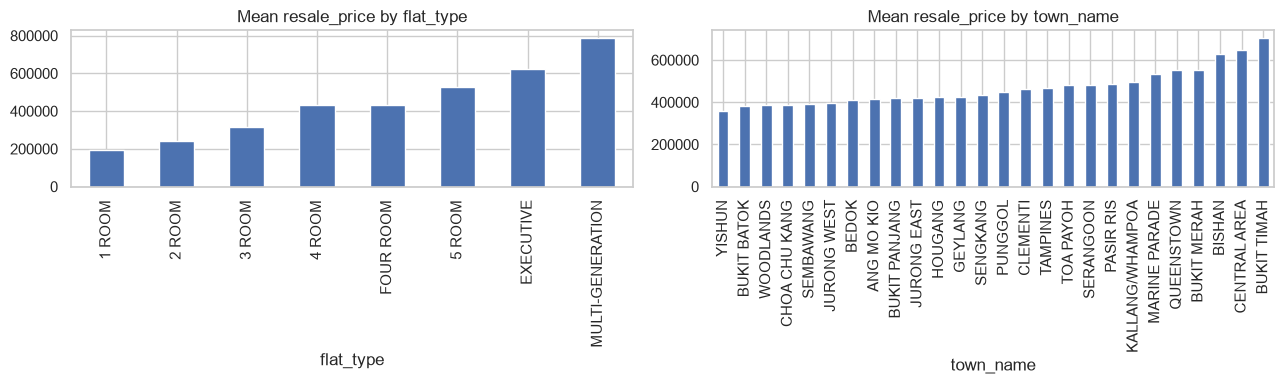

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("flat_type")[TARGET].mean().sort_values().plot(
    kind="bar", ax=ax[0], title="Mean resale_price by flat_type")
df.groupby("town_name")[TARGET].mean().sort_values().plot(
    kind="bar", ax=ax[1], title="Mean resale_price by town_name")
plt.tight_layout(); plt.show()

**Relationship observations.**

- **`floor_area_sqm` is the strongest single predictor** (r ≈ 0.64) — bigger flats cost more,
  as expected. `storey_range` (higher floors, r ≈ 0.38) and `remaining_lease_months`
  (r ≈ 0.34) are the next most useful.
- **`flat_type` tracks price almost monotonically** (1-ROOM ~192k → Multi-Generation ~788k),
  which justifies the ordinal encoding, and confirms `FOUR ROOM` ≈ `4 ROOM`.
- **`town_name` matters a lot** — mature/central towns command far higher prices than newer
  outlying ones, so location (via town) carries real signal.
- `year` / `month` correlate weakly with price (see §10) — the 2015–2019 window was fairly flat.

## 8. Outlier review (IQR)

resale_price: 3708 IQR outliers (4.18%), fence [80000, 760000]
floor_area_sqm: 280 IQR outliers (0.32%), fence [22, 166]


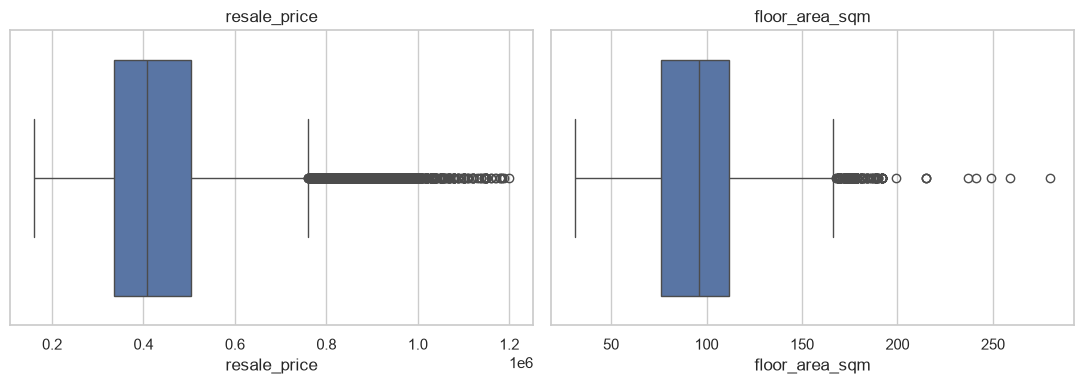

In [13]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum(), lo, hi

for col in [TARGET, "floor_area_sqm"]:
    n, lo, hi = iqr_outliers(df[col])
    print(f"{col}: {n} IQR outliers ({n/len(df)*100:.2f}%), fence [{lo:.0f}, {hi:.0f}]")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df[TARGET], ax=ax[0]); ax[0].set_title("resale_price")
sns.boxplot(x=df["floor_area_sqm"], ax=ax[1]); ax[1].set_title("floor_area_sqm")
plt.tight_layout(); plt.show()

**Outlier decision.** The upper-tail "outliers" are genuine premium transactions (large
executive/multi-gen flats in central towns), not errors — they carry real market signal. We
therefore **keep** them and rely on tree-based models, which are robust to skew and extreme
values, rather than clipping and discarding information.

## 9. Multicollinearity

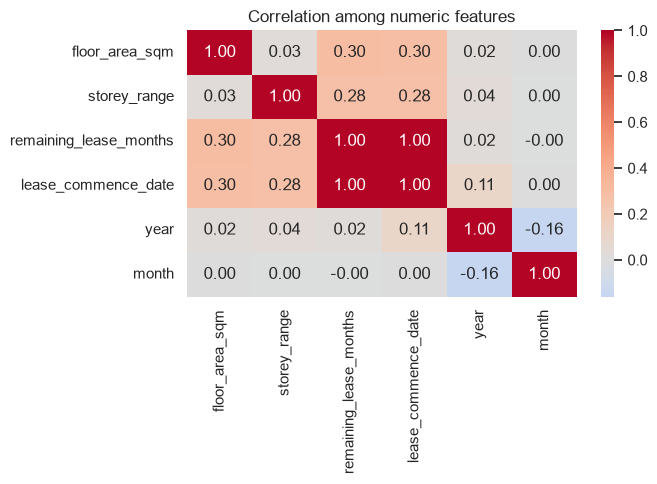

In [14]:
corr = clean[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation among numeric features")
plt.tight_layout(); plt.show()

**Multicollinearity note.** `lease_commence_date` and `remaining_lease_months` are strongly
related — an older commencement year mechanically means fewer months of lease left. They are
near-redundant. Linear models will feel this (unstable coefficients), which is another reason
to include tree/ensemble models that handle correlated predictors gracefully. We keep both for
now but flag the redundancy for the modelling stage.

## 10. Time patterns

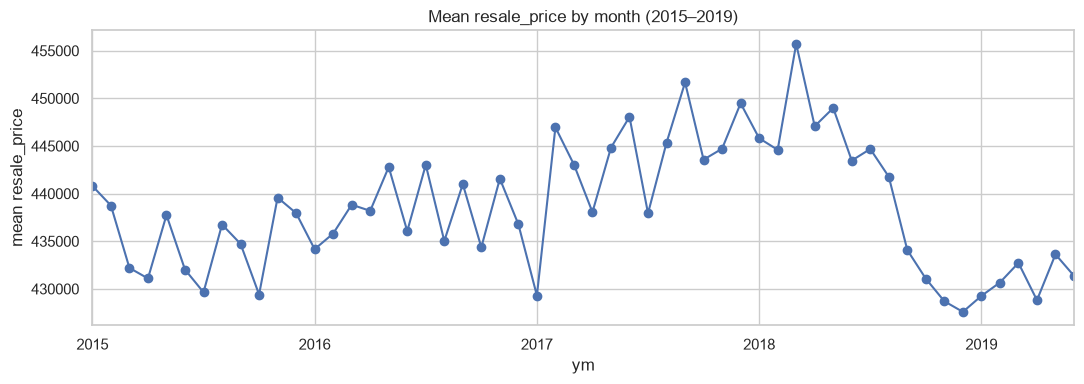

In [15]:
ts = df.copy()
ts["ym"] = pd.to_datetime(ts["month"], format="%Y-%m")
monthly = ts.groupby("ym")[TARGET].mean()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker="o", title="Mean resale_price by month (2015–2019)")
ax.set_ylabel("mean resale_price"); plt.tight_layout(); plt.show()

**Time observation.** Over the 2015–2019 window the average resale price is broadly flat with
mild wobble — no strong trend or obvious seasonality — which is why raw `year` correlates only
weakly with price. `year`/`month` are kept as light features but are not major drivers here.

## 11. Conclusion — findings → preprocessing implications

| EDA finding | Preprocessing / modelling decision |
|---|---|
| 4,223 duplicate rows | Drop exact duplicates |
| `town_name`/`flatm_name` missing but ids present | Back-fill names from id→name map (no rows lost) |
| 9,394 negative `lease_commence_date` | Take absolute value |
| `FOUR ROOM` vs `4 ROOM` | Merge label before encoding |
| `remaining_lease` in two formats | Parse both → `remaining_lease_months` (int) |
| `storey_range` ordered text band | Convert to numeric midpoint |
| `month` = `YYYY-MM` text | Split into numeric `year` + `month` |
| `block`, `street_name`, `id` high-cardinality / identifiers | Drop (leakage & noise risk) |
| `flat_type` ordered, price-monotonic | Ordinal-encode with explicit order |
| `town_name`, `flatm_name` unordered | One-hot encode, `handle_unknown='ignore'` |
| `floor_area_sqm` strongest signal; skewed target; outliers real | Keep features; prefer tree/ensemble models |
| `lease_commence_date` ↔ `remaining_lease_months` collinear | Flag for modelling; favour tree models |

**Next (modelling).** Scale numeric features, encode categoricals as above (all inside a
`ColumnTransformer`/`Pipeline` fit only on training data to avoid leakage), add imputation for
robustness, and compare a `DummyRegressor` baseline against linear models **and** non-linear
ensembles (RandomForest, GradientBoosting), tuned with cross-validated search.